In [1]:
import numpy as np
from scipy.linalg import expm, pinvh, LinAlgError
from scipy.special import comb
from scipy.integrate import *

import matplotlib.pyplot as plt

from electron_integrals import *
from CI_physicist import *

Define functions

In [2]:
# Function to get reduced density matrices

def get_RDMs(num_orbitals, num_electrons, C):
    slater_dets = CIHamiltonian.get_slater_dets(num_orbitals, num_electrons)
    C_conj = C.conj()

    D = np.zeros((num_orbitals,)*2 , dtype=np.cdouble)
    d = np.zeros((num_orbitals,)*4, dtype=np.cdouble)

    for n, det_n in enumerate(slater_dets):
        for m, det_m in enumerate(slater_dets):
            num_differences = np.sum(np.abs(det_n-det_m))
            match(num_differences):
                case 0:
                    for p, n_p in enumerate(det_n):
                        D[p,p] += n_p*C_conj[m]*C[n]
                        for r, n_r in enumerate(det_n):
                            d[p,r,p,r] += n_p*n_r*C_conj[m]*C[n]
                            d[p,r,r,p] -= n_p*n_r*C_conj[m]*C[n] # Note the sign                 
                case 2:
                    p = np.flatnonzero(np.asarray((det_m-det_n)==1))[0]
                    q = np.flatnonzero(np.asarray((det_n-det_m)==1))[0]
                    gamma = (-1)**(np.sum(det_n[:q])+np.sum(det_m[:p]))
                    D[p,q] += gamma*C_conj[m]*C[n]

                    for r, n_r in enumerate(det_n):
                        val = gamma*n_r*C_conj[m]*C[n]
                        d[p,r,q,r] += val
                        d[r,p,q,r] -= val # Note the sign
                        d[p,r,r,q] -= val # Note the sign
                        d[r,p,r,q] += val

                case 4:
                    p,q = np.flatnonzero(np.asarray((det_m-det_n)==1))
                    r,s = np.flatnonzero(np.asarray((det_n-det_m)==1))
                    
                    gamma = np.sum(det_n[:r])
                    gamma += np.sum(det_n[:s])-1 # -1 since r<s 
                    gamma += np.sum(det_n[:q])-int(s<q)-int(r<q)
                    gamma += np.sum(det_n[:p])-int(s<p)-int(r<p) # No additional term since p<q

                    val = C_conj[m]*C[n]*(-1)**gamma
                    d[p,q,r,s] += val
                    d[q,p,r,s] -= val # Note the sign
                    d[p,q,s,r] -= val # Note the sign
                    d[q,p,s,r] += val

    return D, d


# Helper functions to put the problem on a form handled by standard SciPy ODE solvers 

def Cb_to_y(C, b):
    return np.concatenate([C.flatten(), b.flatten()])

def y_to_Cb(y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
    num_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

    C, b = np.split(y, [num_slater_dets])
    b = b.reshape((num_spin_orbitals, num_mctdhf_orbitals))

    return C, b

Define number of electrons and orbitals

In [53]:
# Number of orbitals (without spin)
num_orbitals = 7
# Number of electrons
num_electrons = 1
#Include spin?
include_spin = False

spin_factor = 1+int(include_spin)

num_spin_orbitals = spin_factor*num_orbitals

Calculate electron integrals

In [54]:
def kinetic_energy_mels(i, j, dx):
    with np.errstate(divide='ignore'):
        return np.where(
            i==j,
            np.pi ** 2 / (6 * dx ** 2),
            (-1.0) ** (i_min_j := i - j) / (dx ** 2 * i_min_j **2),
        )

In [55]:
grid = np.linspace(-10, 10, num_orbitals)
dx = np.abs(grid[1] - grid[0])
inds=np.arange(len(grid))
potential = lambda x, omega=1: 0.5 * omega**2 * x ** 2

t = kinetic_energy_mels(inds[:, None], inds[None, :], dx)

h = t + np.diag(potential(grid))

g = shielded_coulomb(grid[:, None], grid[None, :], kappa=1, a=0.01)

# Orbital equations

Define number of MCTDHF orbitals $(\{\ket{\phi_n(t)}\})$, initial b's (basis reduction coefficients),

$\ket{\phi_n(t)} = \sum_{k=1}^{N_b}b_{kn}(t)\ket{\psi_k}$,

and initial C's.


In [56]:
num_mctdhf_orbitals = 3
num_mctdhf_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

# Distributed vales
#b_init = np.zeros((num_spin_orbitals, num_mctdhf_orbitals))
#a = int(num_spin_orbitals/num_mctdhf_orbitals)
#for i in range(num_mctdhf_orbitals):
#    b_init[a*i:a*(i+1), i] = np.ones(a)

# Identity
#b_init=np.eye(num_spin_orbitals, num_mctdhf_orbitals)

# Generate random orthonormal vectors
rng = np.random.default_rng()
r = rng.random((num_spin_orbitals, num_mctdhf_orbitals))
u, _, vh = np.linalg.svd(r, full_matrices=False)
b_init = (u@vh).astype(np.cdouble)*3

print(b_init)

# Ones as initial C
#C_init = np.ones((num_mctdhf_slater_dets), dtype=np.cdouble)

# Random initial C
#C_init = rng.random(num_mctdhf_slater_dets).astype(np.cdouble)

#Normalize
#C_init = np.divide(C_init, np.sqrt(C_init.T.conj()@C_init))

# One element
C_init=np.zeros(num_mctdhf_slater_dets)
C_init[0]=1

print(C_init)

[[-0.53839686+0.j  1.84901989+0.j  1.1572091 +0.j]
 [ 0.32299732+0.j -0.41461672+0.j  1.60386407+0.j]
 [ 1.56560005+0.j -0.366944  +0.j  0.9676147 +0.j]
 [ 1.03093062+0.j  2.01242882+0.j -0.63886887+0.j]
 [ 1.6008234 +0.j -0.62280268+0.j  0.72885732+0.j]
 [-0.78903057+0.j  0.52153882+0.j  1.74965435+0.j]
 [ 1.38082415+0.j  0.75154163+0.j -0.38927135+0.j]]
[1. 0. 0.]


In [58]:
np.linalg.svd(b_init, full_matrices=False)

(array([[-0.17946562+0.j,  0.02093184+0.j, -0.72679389+0.j],
        [ 0.10766577+0.j, -0.52149451+0.j, -0.18156058+0.j],
        [ 0.52186668+0.j, -0.336216  +0.j, -0.07714007+0.j],
        [ 0.34364354+0.j,  0.54928856+0.j, -0.44002044+0.j],
        [ 0.5336078 +0.j, -0.31730491+0.j,  0.03796862+0.j],
        [-0.26301019+0.j, -0.38883424+0.j, -0.46816005+0.j],
        [ 0.46027472+0.j,  0.24692454+0.j, -0.13646385+0.j]]),
 array([3., 3., 3.]),
 array([[ 1.        +0.j,  0.        +0.j,  0.        +0.j],
        [-0.        +0.j,  0.5547002 +0.j, -0.83205029+0.j],
        [ 0.        +0.j, -0.83205029+0.j, -0.5547002 +0.j]]))

Define callable class for the differential equations

In [39]:
class MCDTHF_imaginary_time:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spin_orbitals = num_spin_orbitals
        self.num_electrons = num_electrons
        

    def __call__(self, t, y):
        
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spin_orbitals, self.num_electrons)
        bc = b.conj()

        h_1 = np.einsum('jm, ij -> im', b, self.h)
        h_2 = np.einsum('in, im -> nm', bc, h_1)
        h_3 = np.einsum('in, nm -> in', b, h_2)

        # g_ijkl = delta_ij delta_kl g_ik  
        g_2 = np.einsum('iq, ks, ik -> iqks', bc, b, self.g)
        g_3 = np.einsum('kr, iqks -> iqrs', b, g_2)
        g_4 = np.einsum('ip, iqrs -> pqrs', bc, g_3) # Fully transformed integral
        g_5 = np.einsum('ip, pqrs -> iqrs', b, g_4)

        D, d = get_RDMs(num_mctdhf_orbitals, num_electrons, C)
        
        H = SlaterCondonHamiltonian(self.num_mctdhf_orbitals, self.num_electrons, h_2, g_4).get_hamiltonian()
        
        C_dot = -np.matmul(H,C)
        b_dot = -(h_1-h_3 + np.einsum('np, pqrs, kqrs -> kn', np.linalg.pinv(D), d, g_3-g_5))

        return Cb_to_y(C_dot, b_dot)

Solve using ODE solver

In [59]:
#mctdhf_fun = MCDTHF(h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
mctdhf_fun = MCDTHF_imaginary_time(h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)

y_init = Cb_to_y(C_init, b_init)

Cs = np.copy(C_init).reshape(1,-1)
bs = np.copy(b_init).reshape(1,-1)

h_1 = np.einsum('jm, ij -> im', b_init, h)
h_2 = np.einsum('in, im -> nm', b_init.conj(), h_1)
g_2 = np.einsum('iq, ks, ik -> iqks', b_init.conj(), b_init, g)
g_3 = np.einsum('kr, iqks -> iqrs', b_init, g_2)
g_4 = np.einsum('ip, iqrs -> pqrs', b_init.conj(), g_3) # Fully transformed integral
H = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_2, g_4).get_hamiltonian()
Es = np.array(np.real(C_init.T@H@C_init))

t_init = 0
t_final = 10.0
#solver = DOP853(mctdhf_fun, t_init, y_init, t_final)
solver = RK45(mctdhf_fun, t_init, y_init, t_final)

while solver.status == 'running':
    msg = solver.step()

    C, b = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)

    # Transform with overlap
    #S = np.einsum('pi, qi -> pq', b.conj(), b) #b.conj().T@b
    #_, S_tilde = np.linalg.eigh(S)
    #b = np.einsum('pi, pq -> qi', b, S_tilde)

    b, _, _ = np.linalg.svd(b_init, full_matrices=False)

    # Normalize every step during imaginary time prop
    C = np.divide(C, np.sqrt(C.T.conj()@C))
    b = np.divide(b, np.sqrt(np.einsum('ij, ij -> j', b.conj(), b)))

    h_1 = np.einsum('jm, ij -> im', b, h)
    h_2 = np.einsum('in, im -> nm', b.conj(), h_1)
    g_2 = np.einsum('iq, ks, ik -> iqks', b.conj(), b, g)
    g_3 = np.einsum('kr, iqks -> iqrs', b, g_2)
    g_4 = np.einsum('ip, iqrs -> pqrs', b.conj(), g_3) # Fully transformed integral
    H = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_2, g_4).get_hamiltonian()

    Es = np.append(Es, np.real(C.conj().T@H@C))
    Cs = np.append(Cs, C.reshape(1,-1), axis=0)
    bs = np.append(bs, b.reshape(1,-1), axis=0)

    solver.y = Cb_to_y(C, b)
else:
    if solver.status != 'finished':
        raise(RuntimeError(msg))

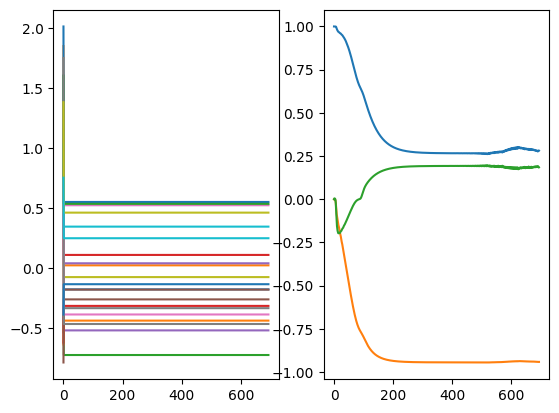

In [60]:
#C_f, b_f = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
#print(b_f)
#print(C_f)
fig, axs = plt.subplots(1,2)
axs[0].plot(np.real(bs))
axs[1].plot(np.real(Cs))
plt.show()

11.589022376287444


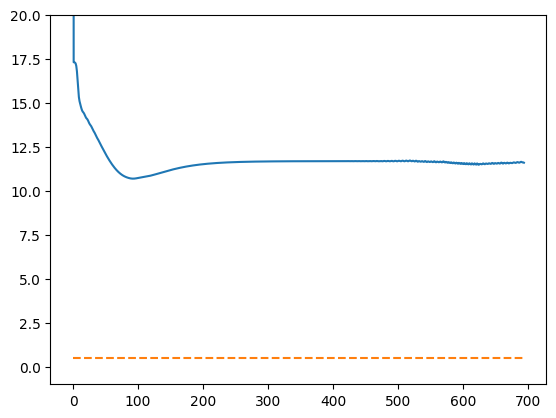

In [63]:
print(Es[-1])
plt.plot(Es)
plt.plot(0.5*np.ones_like(Es), '--')
plt.ylim([-1,20])
plt.show()